In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
import matplotlib as mp
# import gaia_tools as gt
import scipy
from scipy.ndimage import gaussian_filter
import astropy.units as u
from astropy.coordinates import SkyCoord
import math
import h5py
# import healpy as hp
import pykdgrav3_utils
from pykdgrav3_utils import units
un = units.units(1, 600., verbose=True)
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from matplotlib.projections.geo import GeoAxes
# import plotly.graph_objects as go
from matplotlib import colors

sys.path.append('/home/dnurme/linux_env/Thesis/My_thesis/Modules/')
from mock_wake import generate_mock_wake
from rotation_funcs import rotate, angle_finder, rz, ry, rx
from misc import plot_OD_gaussian, overdensity, resultant_OD_gaussian 

# plot_OD_gaussian_interactive, plot_gaussian_interactive

dMsolUnit = 1.000000e+00
dKpcUnit = 6.000000e+02
dGasConst =  1150890.1952769116
dErgPerGmUnit =  71.68174956254887
dGmPerCcUnit =  3.1333829769061664e-40
dSecUnit =  2.1867420491060357e+23
dKmPerSecUnit =  8.466507518602276e-05
dComovingGmPerCcUnit =  3.1333829769061664e-40


In [2]:
file1 = '/home/dnurme/linux_env/Data/dm_sim.00001.0'

def load_snap_file(path, part_type='PartType1', is_print = False):

    snap_file = h5py.File(path, 'r')
    part_data = snap_file[part_type]

    if(is_print):
        print(f'Loading snapshot: {path.split("/")[-1]}')
        print(f'Selected species: {part_type}')
        print(f'Snap file keys: {snap_file.keys()}')
        print(f'Part type keys: {part_data.keys()}')

    return part_data

In [3]:
snap_stars1 = load_snap_file(file1, part_type='PartType4', is_print=True)
star_coord1 = snap_stars1['Coordinates'][:]*un.dKpcUnit

x1 = star_coord1[:,0]
y1 = star_coord1[:,1]
z1 = star_coord1[:,2]

Loading snapshot: dm_sim.00001.0
Selected species: PartType4
Snap file keys: <KeysViewHDF5 ['Cosmology', 'Header', 'Parameters', 'PartType1', 'PartType4', 'Units']>
Part type keys: <KeysViewHDF5 ['Coordinates', 'GroupID', 'Masses', 'ParticleIDs', 'Potential', 'Softening', 'StellarFormationTime', 'Velocities']>


In [4]:
file = '/home/dnurme/linux_env/Data/pos_stars_Plummer_LMC.npy'
data = np.load(file)
x_plum = data[:,0]
y_plum = data[:,1]
z_plum = data[:,2]

star_coord2 = np.array([x_plum, y_plum, z_plum]).T

x2 = star_coord2[:,0]
y2 = star_coord2[:,1]
z2 = star_coord2[:,2]

In [ ]:
# print(star_coord1.shape)
# print(star_coord2.shape)


(<Figure size 1800x600 with 6 Axes>,
 array([<Axes: title={'center': 'Hernquist Overdensity'}>,
        <Axes: title={'center': 'Plummer Overdensity'}>,
        <Axes: title={'center': 'Resultant Overdensity'}>], dtype=object))

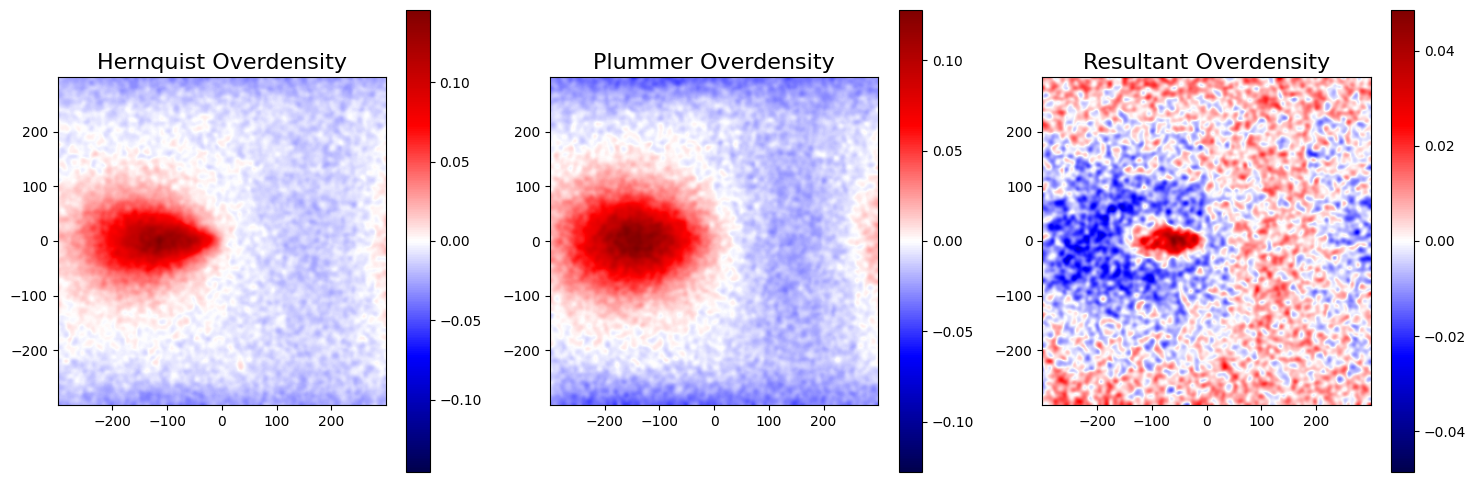

In [7]:
resultant_OD_gaussian(star_coord1, star_coord2, (300, 300), 2, "Hernquist", "Plummer")

In [ ]:
from matplotlib.colors import Normalize

def resultant_OD_gaussian2(data1, data2, bins, sigma, data1_label, data2_label):
    
    def overdensity(x, y, bins):  # generating the overdensity map
        pre_OD, xedges, yedges = np.histogram2d(x, y, bins)
        OD = ((pre_OD / np.mean(pre_OD))-1)
        return OD, xedges, yedges
    
    x1, y1, z1 = data1[:, 0], data1[:, 1], data1[:, 2]
    x2, y2, z2 = data2[:, 0], data2[:, 1], data2[:, 2]

    OD1, xedges1, yedges1 = overdensity(x1, y1, bins)
    OD2, xedges2, yedges2 = overdensity(x2, y2, bins)

    hist_smoothed1 = gaussian_filter(OD1.T, sigma=sigma)
    hist_smoothed2 = gaussian_filter(OD2.T, sigma=sigma)

    resultant_OD = hist_smoothed1 - hist_smoothed2

    fig, axs = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
    im1 = axs[0].polormesh(xedges1, yedges1, hist_smoothed1,cmap="seismic", 
                           norm=Normalize(vmin=-np.max(np.abs(hist_smoothed1)), 
                                          vmax=np.max(np.abs(hist_smoothed1))))
    im2 = axs[1].imshow(xedges2, yedges2, hist_smoothed2, cmap="seismic",
                          norm=Normalize(vmin=-np.max(np.abs(hist_smoothed2)), 
                                          vmax=np.max(np.abs(hist_smoothed2))))
    im3 = axs[2].imshow(xedges1, yedges1, resultant_OD, cmap="seismic",
                          norm=Normalize(vmin=-np.max(np.abs(resultant_OD)), 
                                         vmax=np.max(np.abs(resultant_OD))))
    plt.colorbar(im1, ax=axs[0])
    plt.colorbar(im2, ax=axs[1])
    plt.colorbar(im3, ax=axs[2])
    axs[0].set_title(f'{data1_label} Overdensity', size=16)
    axs[1].set_title(f'{data2_label} Overdensity', size=16)
    axs[2].set_title('Resultant Overdensity', size=16)

    return fig, axs



resultant_OD_gaussian2(star_coord1, star_coord2, (300, 300), 2, "Hernquist", "Plummer")